In [1]:
import pandas as pd
import regex as re
import matplotlib.pyplot as plt
from nltk import download
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from wordcloud import WordCloud
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
import pickle


In [2]:
df = pd.read_csv('../data/raw/12-nlp-url-spam.csv')
df

,url,is_spam
0,https://briefingday.us8.list-manage.com/unsubs...,True
1,https://www.hvper.com/,True
2,https://briefingday.com/m/v4n3i4f3,True
3,https://briefingday.com/n/20200618/m#commentform,False
4,https://briefingday.com/fan,True
...,...,...
2994,https://www.smartcitiesworld.net/news/news/dee...,False
2995,https://www.youtube.com/watch,True
2996,https://techcrunch.com/2019/07/04/an-optimisti...,False
2997,https://www.technologyreview.com/2019/12/20/13...,False


In [3]:
df.dtypes

url        object
is_spam      bool
dtype: object

### 1-Procesamiento-datos

In [4]:
df["is_spam"] = df["is_spam"].apply(lambda x: 1 if x else 0).astype(int)
df["is_spam"]

0       1
1       1
2       1
3       0
4       1
       ..
2994    0
2995    1
2996    0
2997    0
2998    0
Name: is_spam, Length: 2999, dtype: int64

### Conclusiones
-Convertimos la categoria "is_spam" de bool a binario aplicando una lambda y convirtiendo su tipo de dato a entero

In [5]:
df.dtypes
df.shape

(2999, 2)

#### 2-Limpieza


In [6]:
df.duplicated().sum()
df = df.drop_duplicates()
df = df.reset_index(drop=True)
df.shape

(2369, 2)

### Conclusiones
-Eliminamos los duplicados y resetamos el indice(no consrvamos el indice viejo)
-El dataset pasó de 2999 filas a 2369.

### 3-Preprocesamiento

In [7]:
def preprocess_url(url):
    url = url.lower()
    url = re.sub(r'^https?://', '', url)#Elimina el protocolo (http:// o https://) al inicio
    url = re.sub(r'^www\.', '', url)#Elimina el "www." inicial si existe
    url = re.sub(r'#.*$', '', url)#Elimina todo lo que venga después de un "#" (anchors)
    url = re.sub(r'\?.*$', '', url)#Elimina todo lo que venga después de un "?" (query string)
    url = re.sub(r'[-_]+', ' ', url)#Reemplaza guiones y subrayados repetidos por un espacio
    url = re.sub(r'\d+', ' NUM ', url)#Reemplaza cualquier número por el marcador "NUM"
    url = re.sub(r'/', ' ', url)   # reemplaza cada "/" por un espacio
    return url.split()        

df["url"] = df["url"].apply(preprocess_url)
df

,url,is_spam
0,"[briefingday.us, NUM, .list, manage.com, unsub...",1
1,[hvper.com],1
2,"[briefingday.com, m, v, NUM, n, NUM, i, NUM, f...",1
3,"[briefingday.com, n, NUM, m]",0
4,"[briefingday.com, fan]",1
...,...,...
2364,"[theverge.com, NUM, NUM, NUM, NUM, disney, dee...",0
2365,"[smartcitiesworld.net, news, news, deepfake, t...",0
2366,"[techcrunch.com, NUM, NUM, NUM, an, optimistic...",0
2367,"[technologyreview.com, NUM, NUM, NUM, NUM, thi...",0


### 4-Lematización

In [8]:
download("wordnet") #Descargamos el diccionario lexico
lemmatizer = WordNetLemmatizer() #Inicializamos la instancia del objeto

download("stopwords") #Descragamos la lista de palabras comunes
stop_words = stopwords.words("english") #Cargamos la lista de palabras comunes

def lemmatize_text(words, lemmatizer=lemmatizer):
    tokens = [lemmatizer.lemmatize(word) for word in words] #Aplicamos la lematización a cada palabra de lista

    tokens = [word for word in tokens if word not in stop_words]#Filtramos las palabras eliminando las stopwords

    tokens = [word for word in tokens if len(word) > 3]#Filtramos las palabras muy cortas

    return tokens #Devolvemos la lista

[nltk_data] Downloading package wordnet to /home/vscode/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package stopwords to /home/vscode/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [9]:
df["url"] = df["url"].apply(lemmatize_text) #Aplicamos la funcion de lematizacion a cada valor de url
df

,url,is_spam
0,"[briefingday.us, .list, manage.com, unsubscribe]",1
1,[hvper.com],1
2,[briefingday.com],1
3,[briefingday.com],0
4,[briefingday.com],1
...,...,...
2364,"[theverge.com, disney, deepfake, face, swappin...",0
2365,"[smartcitiesworld.net, news, news, deepfake, t...",0
2366,"[techcrunch.com, optimistic, view, deepfakes]",0
2367,"[technologyreview.com, startup, claim, deepfak...",0


### 5-Nube de palabras

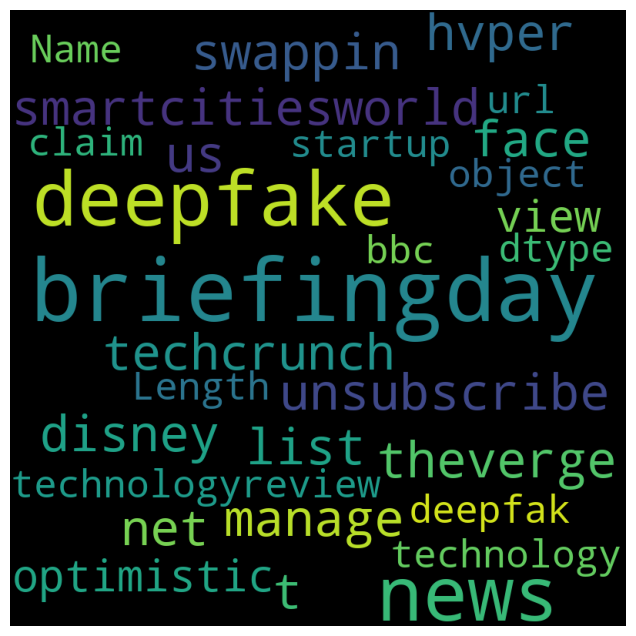

In [10]:
wordcloud = WordCloud(width=800,
                      height=800,
                      background_color="black",
                      max_words=1000,
                      min_font_size=20,
                      random_state=18).generate(str(df["url"]))

fig = plt.figure(figsize=(8, 8), facecolor=None)
plt.imshow(wordcloud)
plt.axis("off")
plt.show()

### 6-Vectorización

In [11]:
tokens_list = df["url"]
tokens_list = [" ".join(tokens) for tokens in tokens_list]#devuelve una lista de strings(urls)

vectorizer = TfidfVectorizer(max_features=5000, #Convertimos el texto en numeros(vectores, matrices numericas)
                             max_df=0.8,
                             min_df=5)

tokens_list

['briefingday.us .list manage.com unsubscribe',
 'hvper.com',
 'briefingday.com',
 'briefingday.com',
 'briefingday.com',
 'brookings.edu interactives reopening america world',
 'reuters.com investigates special report health coronavirus britain',
 'theatlantic.com magazine archive supermarket miracle',
 'vox.com john bolton book excerpt trump ukraine china',
 'theguardian.com travel tourism coronavirus pandemic travel industry',
 'bbc.com future article virus disappeared',
 'narratively.com quarantined hippy trapped jungle paradise',
 'ourworldindata.org grapher daily covid case average',
 'spiked online.com healthy society destroy monument',
 'nytimes.com interactive business economy container ship built.html',
 'aeon.co essay nostalgia rocket fuel power hope change',
 'youtube.com watch',
 'popsci.com story science haribo gummy candy flavor',
 'atlasobscura.com article coffee',
 'outsideonline.com john ackerman cave minnesota',
 'nautil.us issue energy power crossed brain wire',
 's

### 7-Dividir X e y

In [12]:
X = vectorizer.fit_transform(tokens_list).toarray()
y = df["is_spam"]

X[:5]

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(5, 559))

In [13]:
X.shape

(2369, 559)

### 8-Split

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=18, stratify=y)

### 9-Modelado

In [15]:
model = SVC(kernel="linear",
            random_state=18)
model.fit(X_train, y_train)

,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


### Conclusiones

-El modelo SVC implementa el algoritmo SVM que determina la frontera(una linea que divide dos espacios) en la que va a dividir los SPAM y los NO SPAM dependiendo de los patrones encontrados en las palabras.

### 10-prediccion

In [16]:
y_pred_test = model.predict(X_test)
y_pred_train = model.predict(X_train)
y_pred_test

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

### 11-Metricas

In [17]:
def get_classifier_metrics(y_predict_test, y_test, y_predict_train, y_train, average='weighted'):
    metrics_train = (accuracy_score(y_train, y_predict_train),
                     f1_score(y_train, y_predict_train, average=average),
                     precision_score(y_train, y_predict_train, average=average),
                     recall_score(y_train, y_predict_train, average=average))
    metrics_test = (accuracy_score(y_test, y_predict_test),
                    f1_score(y_test, y_predict_test, average=average),
                    precision_score(y_test, y_predict_test, average=average),
                    recall_score(y_test, y_predict_test, average=average))
    return pd.DataFrame(data=[metrics_train, metrics_test],
                        columns=['Accuracy', 'F1 Score', 'Precision', 'Recall'],
                        index=['Train set', 'Test set'])

result = get_classifier_metrics(y_pred_test, y_test, y_pred_train, y_train)
result

,Accuracy,F1 Score,Precision,Recall
Train set,0.944591,0.937761,0.942598,0.944591
Test set,0.934599,0.921934,0.935583,0.934599


In [18]:
cm = confusion_matrix(y_pred_test,y_test)
cm

array([[424,  30],
       [  1,  19]])

### 12-Hiperparametrización

In [19]:
parameters_grid = {'C': [0.01, 0.1, 0.5, 1, 50, 100],
               'class_weight': [None, "balanced"],
               'kernel':['linear','rbf'],
               'tol': [1e-3, 1e-4]}

grid = RandomizedSearchCV(model, parameters_grid, n_iter=15, cv=5, scoring="f1", random_state=18)
grid.fit(X_train, y_train)

print("Mejores parámetros:", grid.best_params_)
print("Mejor modelo:", grid.best_estimator_)

Mejores parámetros: {'tol': 0.001, 'kernel': 'linear', 'class_weight': 'balanced', 'C': 0.1}
Mejor modelo: SVC(C=0.1, class_weight='balanced', kernel='linear', random_state=18)


In [20]:
best_model = grid.best_estimator_
y_pred_best_test = best_model.predict(X_test)
y_pred_best_train = best_model.predict(X_train)
y_pred_best_test




array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

In [21]:
result_best_model = get_classifier_metrics(y_pred_best_test, y_test, y_pred_best_train, y_train)
result_best_model

,Accuracy,F1 Score,Precision,Recall
Train set,0.927177,0.929453,0.932575,0.927177
Test set,0.919831,0.917498,0.915767,0.919831


In [22]:
cm_best = confusion_matrix(y_pred_best_test, y_test)
cm_best

array([[409,  22],
       [ 16,  27]])

### Conclusiones

-Observamos que las metricas del modelo hiperparametrizado son peores a las de modelo base, esto se debe a que el modelo no encontró en la rejilla mejores parametros que los que ya tiene el modelo por defecto

Soluciones a tomar en cuenta:
-Utilizar un rango mayor en los parametros
-Podemos aplicar pipelines para evitar data leakage 
-Hiperparametrizar tambien el vectorizador

-Aún asi obtuvimos una mejor prediccion en el modelo base despues de pasarle el parametro stratify=y al split, lo que nos indica la importancia de este en datasets de CLASIFICACION  ya que balancea la distribucion de datos, es decir, utiliza la misma proporcion tanto en el conjunto de prueba como de entrenamiento, asi evitamos que el modelo se entrene con una distribucion distinta con la que se hacen las pruebas.

### 13-Guardado

In [23]:
# Guardar Vectorizador
with open('../models/vectorizer-url-spam.pkl', 'wb') as f:
    pickle.dump(vectorizer, f)

# Guardar SVC
with open('../models/SVC-url-spam.pkl', 'wb') as f:
    pickle.dump(model, f)

In [24]:
def spam_or_not_spam(predict):
    mapping = {0:"NO SPAM",1:"SPAAAM"}
    return mapping[predict]

result_spam = spam_or_not_spam(y_pred_best_test[-1])
result_spam

'NO SPAM'